In [10]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.171  Python-3.14.3 torch-2.14.1+cu132 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
Setup complete  (16 CPUs, 63.7 GB RAM, 345.8/474.7 GB disk)


In [11]:
import torch

print(f"PyTorch version: {torch.version}") 
cuda_available = torch.cuda.is_available() 
print(f"CUDA available: {cuda_available}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
print(f"Using device: {device}")

PyTorch version: <module 'torch.version' from 'c:\\Users\\USER\\Desktop\\uni\\semestre 9\\vision por computadora\\entregable 1\\vision-por-computador\\.venv\\Lib\\site-packages\\torch\\version.py'>
CUDA available: True
Using device: cuda


In [13]:

import os
import random
import cv2
import xml.etree.ElementTree as ET
import numpy as np
from ultralytics import SAM
import gc
import matplotlib.pyplot as plt

Model summary: 178 layers, 93,735,472 parameters, 93,735,472 gradients

image 1/1 c:\Users\USER\Desktop\uni\semestre 9\vision por computadora\entregable 1\vision-por-computador\guia-3\MASATI-v2\coast_ship\x0566.png: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 3107.7ms
Speed: 5.6ms preprocess, 3107.7ms inference, 2.1ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 c:\Users\USER\Desktop\uni\semestre 9\vision por computadora\entregable 1\vision-por-computador\guia-3\MASATI-v2\multi\m0230.png: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 3100.0ms
Speed: 5.2ms preprocess, 3100.0ms inference, 0.9ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 c:\Users\USER\Desktop\uni\semestre 9\vision por computadora\entregable 1\vision-por-computador\guia-3\MASATI-v2\ship\s0913.png: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 3020.1ms
Speed: 5.0ms preprocess, 3020.1ms inference, 1.2ms post

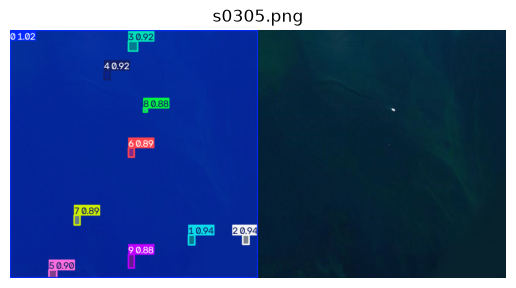

In [18]:
model = SAM("sam_b.pt")
model.info()
dataset_base_path = "MASATI-v2"
masati_content = os.listdir(dataset_base_path)
with_labels = {}

# find folders with labels
for folder in masati_content: 
    if folder.endswith("_labels"):
        with_labels[folder.replace("_labels", "")] = folder

images =[]

for _ in range(7):
    for data, label in with_labels.items():
        data_path = os.path.join(dataset_base_path, data)
        image = random.choice(os.listdir(data_path))

        images.append(os.path.join(data_path, image))

        results = model(os.path.join(data_path, image))

        img = results[0].plot()

        cv2.imwrite(os.path.join(dataset_base_path, "AutoSegmentacion", image[:-4]+"_AUTO.png"), img)

# Convertir a RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_ori = cv2.cvtColor(cv2.imread(images[-1]), cv2.COLOR_BGR2RGB)
img_CONCAT = cv2.hconcat([img_rgb, img_ori])

# Mostrar con Matplotlib
plt.imshow(img_CONCAT)
plt.title(image)
plt.axis("off")
plt.show()

gc.collect()
torch.cuda.empty_cache()


In [ ]:
def save_voc_xml(results, image_path, xml_path, class_name="ship"):
    h, w = results.orig_shape            # (alto, ancho) de la imagen original
    boxes = results.boxes.xyxy.cpu().numpy()

    root = ET.Element("annotation")
    ET.SubElement(root, "folder").text = os.path.basename(os.path.dirname(image_path))
    ET.SubElement(root, "filename").text = os.path.basename(image_path)

    size = ET.SubElement(root, "size")
    ET.SubElement(size, "width").text = str(w)
    ET.SubElement(size, "height").text = str(h)
    ET.SubElement(size, "depth").text = "3"

    for x1, y1, x2, y2 in boxes:
        obj = ET.SubElement(root, "object")
        ET.SubElement(obj, "name").text = class_name
        ET.SubElement(obj, "pose").text = "Unspecified"
        ET.SubElement(obj, "truncated").text = "0"
        ET.SubElement(obj, "difficult").text = "0"

        bnd = ET.SubElement(obj, "bndbox")
        ET.SubElement(bnd, "xmin").text = str(int(round(x1)))
        ET.SubElement(bnd, "ymin").text = str(int(round(y1)))
        ET.SubElement(bnd, "xmax").text = str(int(round(x2)))
        ET.SubElement(bnd, "ymax").text = str(int(round(y2)))

    tree = ET.ElementTree(root)
    ET.indent(tree, space="  ")          
    tree.write(xml_path, encoding="utf-8", xml_declaration=True)

dataset_base_path = "MASATI-v2"
xml_path = os.path.join("MASATI-v2", "ships_SAM")

for image in images:
    split = image.split('\\')
    tree = ET.parse(os.path.join(dataset_base_path, split[1]+"_labels", split[2].replace(".png", ".xml")))
    root = tree.getroot()
    rectangles = []
    for obj in root.findall("object"):
        bbox = obj.find("bndbox")

        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        rectangles.append((xmin, ymin, xmax, ymax))

    results = model(image, bboxes=rectangles)

    save_voc_xml(results[0], image, os.path.join(xml_path,split[2][:-4]+".xml"), class_name="ship")


gc.collect()
torch.cuda.empty_cache()



image 1/1 c:\Users\USER\Desktop\uni\semestre 9\vision por computadora\entregable 1\vision-por-computador\guia-3\MASATI-v2\coast_ship\x0566.png: 1024x1024 1 0, 319.0ms
Speed: 5.9ms preprocess, 319.0ms inference, 1.3ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 c:\Users\USER\Desktop\uni\semestre 9\vision por computadora\entregable 1\vision-por-computador\guia-3\MASATI-v2\multi\m0230.png: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 248.4ms
Speed: 5.5ms preprocess, 248.4ms inference, 1.3ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 c:\Users\USER\Desktop\uni\semestre 9\vision por computadora\entregable 1\vision-por-computador\guia-3\MASATI-v2\ship\s0913.png: 1024x1024 1 0, 228.0ms
Speed: 5.4ms preprocess, 228.0ms inference, 1.1ms postprocess per image at shape (1, 3, 1024, 1024)

image 1/1 c:\Users\USER\Desktop\uni\semestre 9\vision por computadora\entregable 1\vision-por-computador\guia-3\MASATI-v2\coast_ship\x0412.png: 1024x1024 1 0, 228.9ms

In [ ]:
dataset_base_path = "MASATI-v2"
SAM_path = os.path.join(dataset_base_path, "ships_SAM")
SAM_content = os.listdir(SAM_path)

for file in SAM_content:

    tree = ET.parse(os.path.join(SAM_path, file))
    root = tree.getroot()

    image = os.path.join(dataset_base_path, root.find('folder').text, root.find('filename').text)

    rectangles_SAM = []
    for obj in root.findall("object"):
        bbox = obj.find("bndbox")

        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        rectangles_SAM.append((xmin, ymin, xmax, ymax))


    cv2_img = cv2.imread(image)
    img_SAM = cv2_img.copy()
    for (x1,y1,x2,y2) in rectangles_SAM:
        cv2.rectangle(img_SAM, (x1,y1), (x2, y2), (0,0,255), 1)

    tree = ET.parse(os.path.join(dataset_base_path, root.find('folder').text+"_labels", root.find('filename').text.replace(".png", ".xml")))
    root = tree.getroot()
    rectangles_xml = []
    for obj in root.findall("object"):
        bbox = obj.find("bndbox")

        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        rectangles_xml.append((xmin, ymin, xmax, ymax))

    img_xml = cv2_img.copy()
    for (x1,y1,x2,y2) in rectangles_xml:
        cv2.rectangle(img_xml, (x1,y1), (x2, y2), (0,0,255), 1)

    img_CONCAT = cv2.hconcat([img_SAM,img_xml])

    cv2.imshow(image, img_CONCAT)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

MASATI-v2\multi\m0114.png
MASATI-v2\multi\m0150.png
MASATI-v2\multi\m0211.png
MASATI-v2\multi\m0222.png
MASATI-v2\multi\m0224.png
MASATI-v2\multi\m0230.png
MASATI-v2\ship\s0305.png
MASATI-v2\ship\s0571.png
MASATI-v2\ship\s0594.png
MASATI-v2\ship\s0812.png
MASATI-v2\ship\s0834.png
MASATI-v2\ship\s0859.png
MASATI-v2\ship\s0913.png
MASATI-v2\coast_ship\x0191.png
MASATI-v2\coast_ship\x0209.png
MASATI-v2\coast_ship\x0405.png
MASATI-v2\coast_ship\x0412.png
MASATI-v2\coast_ship\x0451.png
MASATI-v2\coast_ship\x0566.png
MASATI-v2\coast_ship\x0711.png
MASATI-v2\multi\y0031.png
